# Explorer les données pour choisir la régression

Ce notebook lit les trois fichiers du dossier `input/` (salariés, grille interne, marché), fait le ménage nécessaire, puis montre en graphes **ce qui fait le salaire**.

Le but : décider de ce qu'on met dans la régression de `src/anomaly_signal_regression.py`. Aujourd'hui, elle prédit le salaire à partir de :
- pour un **nouvel embauché** : métier, grade, âge, Hot_job ;
- pour un **salarié déjà là** : les mêmes, plus l'ancienneté, la note de compétence et la case 9-Box.

Chaque graphe répond à une question. Au-dessus de chacun : pourquoi on le regarde, comment le lire, et quel choix il aide à trancher.

| Question | Où regarder |
|---|---|
| Quelles colonnes sont inutilisables ? | section 2 |
| Faut-il garder le « log » du salaire ? | section 3 |
| Le grade : en catégories ou en nombre ? | section 4 |
| Faut-il croiser métier et grade ? | section 4 |
| Âge, ancienneté, compétence, 9-Box, Hot_job : apportent-ils quelque chose ? | section 5 |
| Des colonnes qui disent la même chose ? | section 6 |
| Quel ensemble de colonnes prédit le mieux ? Quel seuil pour signaler ? | section 7 |

## 1. Lire les fichiers

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Le dossier du projet : celui qui contient input/ (le notebook marche lancé depuis notebooks/ ou depuis la racine)
PROJET = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "input" / "employes.xlsx").is_file())

# Couleurs des graphes
BLEU, ORANGE, VERT = "#2a78d6", "#eb6834", "#1baf7a"
ENCRE, ENCRE_2, GRIS, GRIS_CLAIR, GRILLE, FOND = "#0b0b0b", "#52514e", "#898781", "#c3c2b7", "#e1e0d9", "#fcfcfb"
BLEUS = LinearSegmentedColormap.from_list("bleus", ["#e6f0fc", "#9ec5f4", "#5598e7", "#256abf", "#104281"])
BLEU_ROUGE = LinearSegmentedColormap.from_list("bleu_rouge", ["#1c5cab", "#86b6ef", "#f0efec", "#f0a3a2", "#c53a39"])

plt.rcParams.update({
    "figure.facecolor": FOND, "axes.facecolor": FOND,
    "axes.edgecolor": GRIS_CLAIR, "axes.labelcolor": ENCRE_2,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlecolor": ENCRE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRILLE, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": GRIS, "ytick.color": GRIS, "xtick.labelcolor": ENCRE_2, "ytick.labelcolor": ENCRE_2,
    "text.color": ENCRE, "lines.linewidth": 2,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "legend.frameon": False,
})


def echelle_en_pourcentages(ax, axe="y"):
    # Échelle où chaque doublement prend la même place : de 100 à 200 = de 400 à 800
    (ax.set_yscale if axe == "y" else ax.set_xscale)("log")
    a = ax.yaxis if axe == "y" else ax.xaxis
    a.set_major_locator(mticker.FixedLocator([50, 75, 100, 150, 200, 300, 400, 600, 800, 1000]))
    a.set_major_formatter(mticker.FormatStrFormatter("%d"))
    a.set_minor_locator(mticker.NullLocator())

In [2]:
employes = pd.read_excel(PROJET / "input" / "employes.xlsx")
bands = pd.read_excel(PROJET / "input" / "bands.xlsx")
market = pd.read_excel(PROJET / "input" / "market.xlsx")

for nom, tableau in [("employes", employes), ("bands", bands), ("market", market)]:
    print(f"{nom:9} : {tableau.shape[0]:>6} lignes, {tableau.shape[1]:>2} colonnes")
employes.head()

employes  :  10000 lignes, 18 colonnes
bands     :     91 lignes,  7 colonnes
market    :     91 lignes,  7 colonnes


,Matricule,Nom,Entite_N1,Entite_N2,Pays,Job_Family,Job_Title,Grade,Fixe_Annuel_MAD,Age,Anciennete,Sexe,FTE,Devise,Date_Effet_Paie,Competence_N1,Positionnement_9BOX,Hot_job
0,Mat00001,NaN,Pole 3,P3-E05,Maroc,RETAIL BANKING,JT1389,5,238.34,28,8,F,1,MAD,01/08/2025,4.09,6,4
1,Mat00002,NaN,Pole 3,P3-E16,Maroc,RETAIL BANKING,JT1109,3,339.68,27,2,M,1,MAD,01/08/2025,4.14,0,0
2,Mat00003,NaN,Pole 3,P3-E13,Maroc,RETAIL BANKING,JT1103,2,431.35,39,10,M,1,MAD,01/08/2025,2.63,0,2
3,Mat00004,NaN,Pole 4,P4-E01,Maroc,FINANCE,JT0355,4,188.43,49,1,M,1,MAD,01/08/2025,3.22,1,5
4,Mat00005,NaN,Pole 4,P4-E08,Maroc,IT,JT0939,7,184.34,37,5,M,1,MAD,01/08/2025,2.99,0,0


## 2. Faire le ménage

### Ce que contient chaque colonne

**Pourquoi.** Avant de chercher ce qui explique le salaire, on écarte ce qui ne peut rien expliquer.

**Comment lire.** Une colonne qui n'a qu'**une seule valeur** (tout le monde est au Maroc, tout le monde est à temps plein…) ou qui est **entièrement vide** ne distingue personne : elle ne peut pas expliquer une différence de salaire. À l'inverse, une colonne avec **une valeur par salarié** (le matricule) est une étiquette, pas une explication.

In [3]:
pd.DataFrame({
    "type": employes.dtypes.astype(str),
    "valeurs différentes": employes.nunique(),
    "cases vides": employes.isna().sum(),
    "exemple (1re ligne)": employes.iloc[0],
})

,type,valeurs différentes,cases vides,exemple (1re ligne)
Matricule,object,10000,0,Mat00001
Nom,float64,0,10000,NaN
Entite_N1,object,5,0,Pole 3
Entite_N2,object,72,0,P3-E05
Pays,object,1,0,Maroc
Job_Family,object,13,0,RETAIL BANKING
Job_Title,object,2000,0,JT1389
Grade,int64,7,0,5
Fixe_Annuel_MAD,float64,8732,0,238.34
Age,int64,41,0,28


### Doublons, colonnes inutiles, et ajout de la grille et du marché

On fait comme le reste du projet (`src/anomaly_pretraitement.py`) : un matricule en double ou un même métier + grade présent deux fois dans la grille ou le marché, on garde le premier. Puis on retire les colonnes à une seule valeur, et on ajoute à chaque salarié sa fourchette de grille (`Min`, `Mid`, `Max`) et la médiane du marché, retrouvées par son métier et son grade.

In [4]:
cles = ["Job_Family", "Grade"]
print("Matricules en double :", employes["Matricule"].duplicated().sum())
print("Métier + grade en double : bands", bands.duplicated(cles).sum(), "| market", market.duplicated(cles).sum())
employes = employes.drop_duplicates("Matricule")
bands = bands.drop_duplicates(cles)
market = market.drop_duplicates(cles)

# Une seule valeur (ou aucune) : la colonne ne distingue personne
inutiles = [c for c in employes.columns if employes[c].nunique() <= 1]
print("Colonnes écartées :", inutiles)

df = (employes.drop(columns=inutiles)
      .merge(bands[cles + ["Min", "Mid", "Max"]], on=cles, how="left")
      .merge(market[cles + ["Median"]].rename(columns={"Median": "Market_Median"}), on=cles, how="left"))
print("Salariés sans grille :", df["Mid"].isna().sum(), "| sans marché :", df["Market_Median"].isna().sum())

# Mêmes tranches d'ancienneté que dans src/anomaly_pretraitement.py
df["Anciennete_Tranche"] = pd.cut(df["Anciennete"], [-1, 2, 5, 12, 20, np.inf],
                                  labels=["0-2", "3-5", "6-12", "13-20", ">20"])

Matricules en double : 0
Métier + grade en double : bands 0 | market 0
Colonnes écartées : ['Nom', 'Pays', 'FTE', 'Devise', 'Date_Effet_Paie']
Salariés sans grille : 0 | sans marché : 0


### La grille interne et le marché disent-ils la même chose ?

**Pourquoi.** La régression pourrait utiliser le milieu de la grille (`Mid`) ou la médiane du marché comme repère. Si les deux sont identiques, inutile de se poser la question : l'un ou l'autre, c'est pareil.

**Comment lire.** Chaque point est un couple métier + grade. Sur la diagonale, le marché paie exactement le `Mid` de la grille ; au-dessus, le marché paie plus ; en dessous, moins.

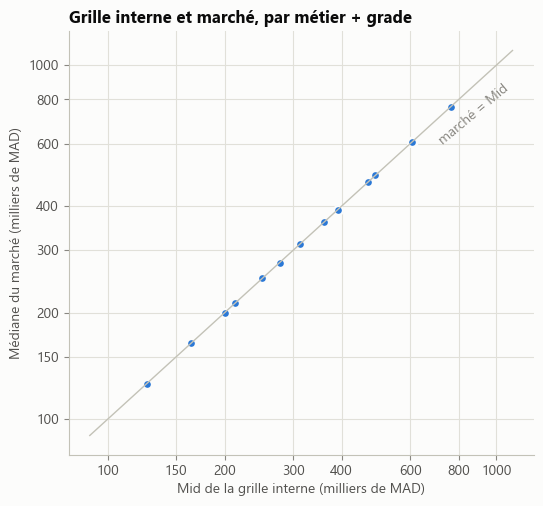

Écart marché / Mid : de +0.0 % à +0.0 % (100% des couples à moins de 0,5 %)


In [5]:
grille_marche = bands.merge(market, on=cles)
ecart = 100 * (grille_marche["Median"] / grille_marche["Mid"] - 1)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([90, 1100], [90, 1100], color=GRIS_CLAIR, linewidth=1)
ax.text(700, 600, "marché = Mid", color=GRIS, rotation=40)
ax.scatter(grille_marche["Mid"], grille_marche["Median"], s=40, color=BLEU, edgecolor=FOND, linewidth=1.5)
echelle_en_pourcentages(ax, "x")
echelle_en_pourcentages(ax, "y")
ax.set_xlabel("Mid de la grille interne (milliers de MAD)")
ax.set_ylabel("Médiane du marché (milliers de MAD)")
ax.set_title("Grille interne et marché, par métier + grade")
plt.show()
print(f"Écart marché / Mid : de {ecart.min():+.1f} % à {ecart.max():+.1f} % ({(ecart.abs() < 0.5).mean():.0%} des couples à moins de 0,5 %)")

## 3. Le salaire lui-même : faut-il le « log » ?

**Le log, en clair.** Prendre le log du salaire revient à raisonner **en pourcentages** plutôt qu'en dirhams : passer de 100 à 200 compte autant que passer de 400 à 800 (les deux sont « × 2 »). Sur les graphes, on ne montre jamais le log lui-même : on garde les vrais salaires, mais sur une échelle où chaque doublement prend la même place (à droite ci-dessous).

### La répartition des salaires

**Comment lire.** À gauche, en milliers de MAD : si la bosse est collée à gauche avec une longue traîne vers les hauts salaires, la moyenne est tirée vers le haut par quelques gros salaires. À droite, sur l'échelle en % : si la bosse devient plus équilibrée, raisonner en % décrit mieux les salaires.

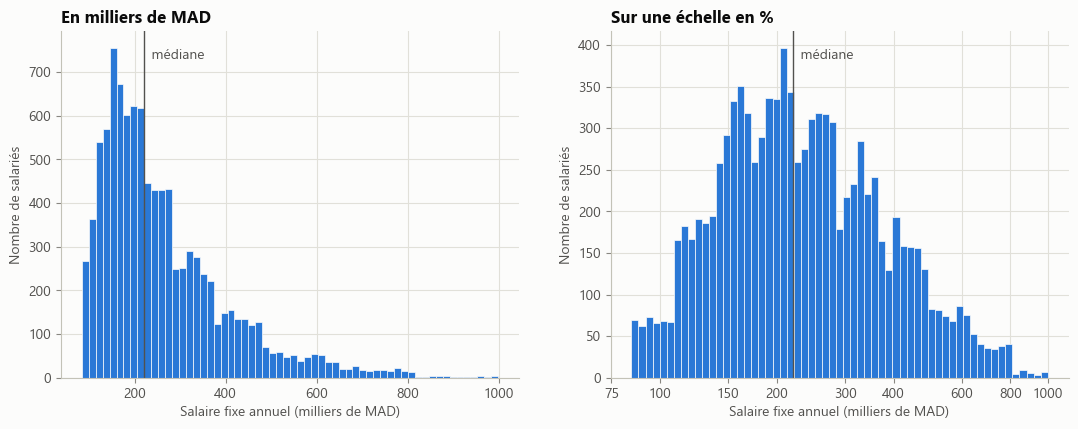

Moyenne 262 | médiane 221 | du plus bas au plus haut : 84 à 998


In [6]:
salaire = df["Fixe_Annuel_MAD"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.hist(salaire, bins=60, color=BLEU, edgecolor=FOND, linewidth=0.5)
ax1.set_title("En milliers de MAD")

ax2.hist(salaire, bins=np.geomspace(salaire.min(), salaire.max(), 60), color=BLEU, edgecolor=FOND, linewidth=0.5)
echelle_en_pourcentages(ax2, "x")
ax2.set_title("Sur une échelle en %")

for ax in (ax1, ax2):
    ax.axvline(salaire.median(), color=ENCRE_2, linewidth=1)
    ax.text(salaire.median(), ax.get_ylim()[1] * 0.95, "  médiane", color=ENCRE_2, va="top")
    ax.set_xlabel("Salaire fixe annuel (milliers de MAD)")
    ax.set_ylabel("Nombre de salariés")
plt.show()
print(f"Moyenne {salaire.mean():.0f} | médiane {salaire.median():.0f} | du plus bas au plus haut : {salaire.min():.0f} à {salaire.max():.0f}")

### L'écart des salaires à l'intérieur de chaque grade

**Pourquoi.** C'est le graphe qui décide vraiment pour le log. La régression mesure l'écart de chaque salarié à son salaire attendu, puis le compare à « l'erreur normale du modèle » (une seule valeur pour tout le monde, dans `Reg_Z`). Cela n'a de sens que si cette erreur normale est **à peu près la même dans tous les grades**.

**Comment lire.** Chaque boîte contient la moitié des salariés du grade (le trait du milieu est la médiane). Grade 1 = le plus haut, grade 7 = le plus bas. Si, en milliers de MAD (à gauche), les boîtes grandissent avec le salaire alors que, sur l'échelle en % (à droite), elles gardent la même taille : **il faut le log**. Sans log, un même seuil serait trop sévère pour les petits salaires et trop indulgent pour les gros.

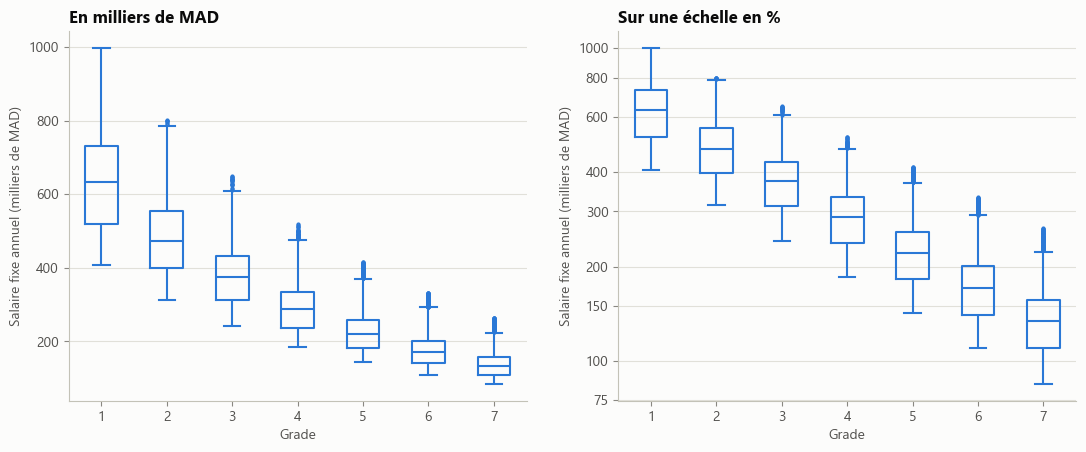

,count,25%,50%,75%,taille de la boîte (MAD),taille de la boîte (% de la médiane)
Grade,,,,,,
1,422.0,519.9,632.9,732.3,212.3,33.5
2,699.0,398.7,473.0,555.7,157.0,33.2
3,1110.0,313.2,375.4,431.2,118.1,31.4
4,1664.0,237.2,287.5,333.3,96.1,33.4
5,2190.0,182.4,220.5,257.2,74.8,33.9
6,2192.0,140.3,171.1,201.3,60.9,35.6
7,1723.0,109.8,134.1,156.5,46.7,34.8


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
for ax in (ax1, ax2):
    sns.boxplot(data=df, x="Grade", y="Fixe_Annuel_MAD", ax=ax, color=BLEU, fill=False, width=0.5,
                linewidth=1.5, fliersize=2)
    ax.set_ylabel("Salaire fixe annuel (milliers de MAD)")
ax1.set_title("En milliers de MAD")
echelle_en_pourcentages(ax2)
ax2.set_title("Sur une échelle en %")
plt.show()

par_grade = df.groupby("Grade")["Fixe_Annuel_MAD"].describe()[["count", "25%", "50%", "75%"]]
par_grade["taille de la boîte (MAD)"] = par_grade["75%"] - par_grade["25%"]
par_grade["taille de la boîte (% de la médiane)"] = 100 * par_grade["taille de la boîte (MAD)"] / par_grade["50%"]
par_grade.round(1)

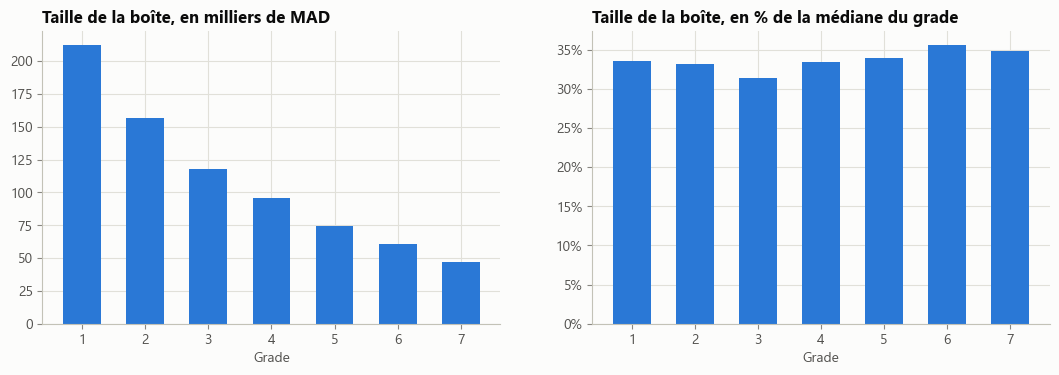

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8), sharex=True)
ax1.bar(par_grade.index, par_grade["taille de la boîte (MAD)"], color=BLEU, width=0.6)
ax1.set_title("Taille de la boîte, en milliers de MAD")
ax2.bar(par_grade.index, par_grade["taille de la boîte (% de la médiane)"], color=BLEU, width=0.6)
ax2.set_title("Taille de la boîte, en % de la médiane du grade")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
for ax in (ax1, ax2):
    ax.set_xlabel("Grade")
plt.show()

## 4. Métier et grade : ce qui fixe le niveau du salaire

### Combien gagne-t-on en montant d'un grade ?

**Pourquoi.** Aujourd'hui, la régression traite le grade **en catégories** (une colonne 0/1 par grade : chaque grade a sa propre valeur). On pourrait aussi le traiter **comme un nombre** (une seule valeur : « chaque grade de plus rapporte x % »). C'est plus simple, mais seulement si le pas est le même d'un grade à l'autre.

**Comment lire.** Médiane des salaires de chaque grade, sur l'échelle en %. Si les points sont **alignés** (pas réguliers, en %), le grade peut entrer comme un nombre. S'ils font des marches inégales, on le garde en catégories.

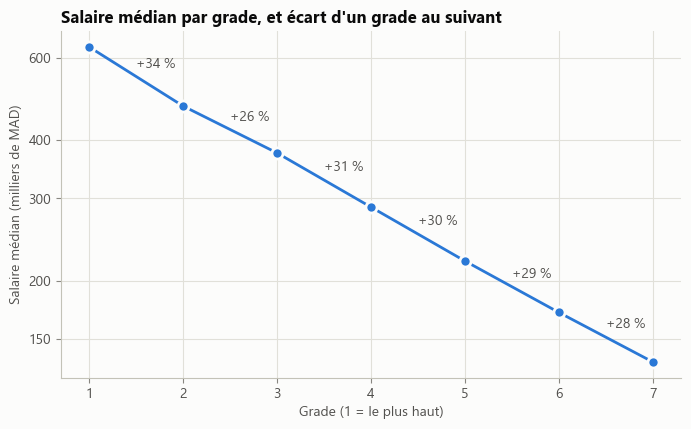

In [9]:
mediane_grade = df.groupby("Grade")["Fixe_Annuel_MAD"].median()
# Ce qu'on gagne en passant du grade g+1 au grade g (le grade 1 est le plus haut)
gain = {g: 100 * (mediane_grade[g] / mediane_grade[g + 1] - 1) for g in mediane_grade.index[:-1]}

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mediane_grade.index, mediane_grade.values, color=BLEU, marker="o", markersize=8,
        markeredgecolor=FOND, markeredgewidth=2)
for g, v in gain.items():
    milieu = np.sqrt(mediane_grade[g] * mediane_grade[g + 1])
    ax.text(g + 0.5, milieu * 1.03, f"{v:+.0f} %", ha="left", va="bottom", color=ENCRE_2)
echelle_en_pourcentages(ax)
ax.set_xlabel("Grade (1 = le plus haut)")
ax.set_ylabel("Salaire médian (milliers de MAD)")
ax.set_title("Salaire médian par grade, et écart d'un grade au suivant")
plt.show()

### Les métiers

**Pourquoi.** Vérifier que le métier change bien le niveau de salaire (sinon, inutile de le mettre).

**Comment lire.** Une boîte par métier, triées par salaire médian, sur l'échelle en %. Le nombre entre parenthèses est l'effectif. Attention : chaque métier a ses propres grades, donc une différence ici peut venir du métier **ou** de sa pyramide de grades ; la carte suivante sépare les deux.

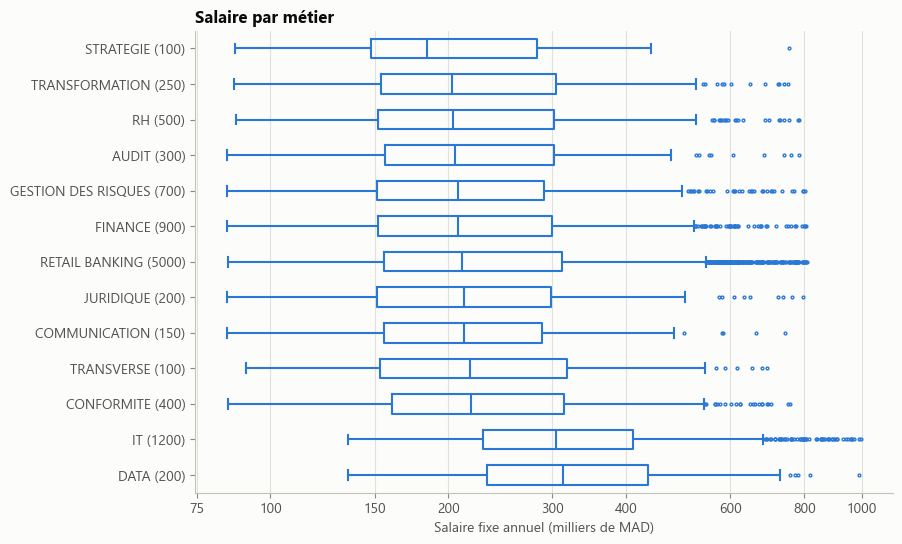

In [10]:
ordre = df.groupby("Job_Family")["Fixe_Annuel_MAD"].median().sort_values().index
effectifs = df["Job_Family"].value_counts()

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, y="Job_Family", x="Fixe_Annuel_MAD", order=ordre, ax=ax, color=BLEU, fill=False,
            width=0.55, linewidth=1.5, fliersize=2)
ax.set_yticks(range(len(ordre)), [f"{m} ({effectifs[m]})" for m in ordre])
echelle_en_pourcentages(ax, "x")
ax.set_xlabel("Salaire fixe annuel (milliers de MAD)")
ax.set_ylabel("")
ax.set_title("Salaire par métier")
plt.show()

### Le salaire médian de chaque case métier × grade

**Comment lire.** Une ligne par métier, une colonne par grade ; plus c'est foncé, plus le salaire médian est élevé. On y lit d'un coup l'effet du grade (de gauche à droite) et celui du métier (de haut en bas).

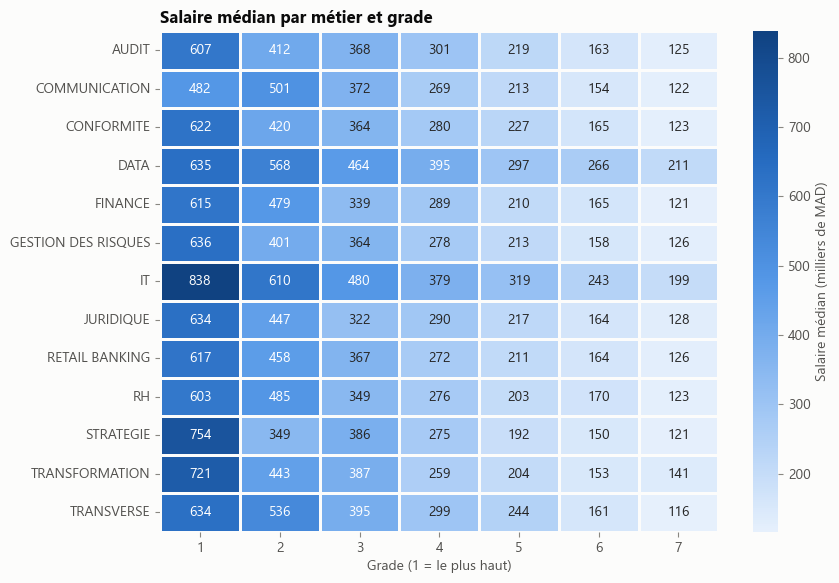

In [11]:
carte = df.pivot_table(index="Job_Family", columns="Grade", values="Fixe_Annuel_MAD", aggfunc="median")
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(carte, annot=True, fmt=".0f", cmap=BLEUS, linewidths=2, linecolor=FOND, ax=ax,
            cbar_kws={"label": "Salaire médian (milliers de MAD)"})
ax.set_xlabel("Grade (1 = le plus haut)")
ax.set_ylabel("")
ax.set_title("Salaire médian par métier et grade")
ax.grid(False)
plt.show()

### Faut-il croiser métier et grade ?

**Pourquoi.** La régression actuelle **additionne** un effet métier et un effet grade : « être en IT, c'est x % de plus, quel que soit le grade ». Si l'avantage d'un métier change selon le grade (par exemple +50 % chez les juniors mais +20 % chez les directeurs), l'addition se trompe : il faudrait **croiser** métier et grade (une valeur par case), ou passer par le `Mid` de la grille qui contient déjà ce croisement.

**Comment lire (petits graphes).** Un petit graphe par métier : en bleu le métier, en gris tous les autres. Sur l'échelle en %, si la ligne bleue est **parallèle** aux grises, l'addition suffit. Si elle est plus pentue ou plus plate, il faut croiser.

**Comment lire (carte en couleurs).** Pour chaque case : de combien le métier est au-dessus (rouge) ou en dessous (bleu) du salaire médian de **tout le grade**. Une ligne **de couleur uniforme** = un écart constant = l'addition suffit. Une ligne qui **change de couleur** d'un bout à l'autre = il faut croiser.

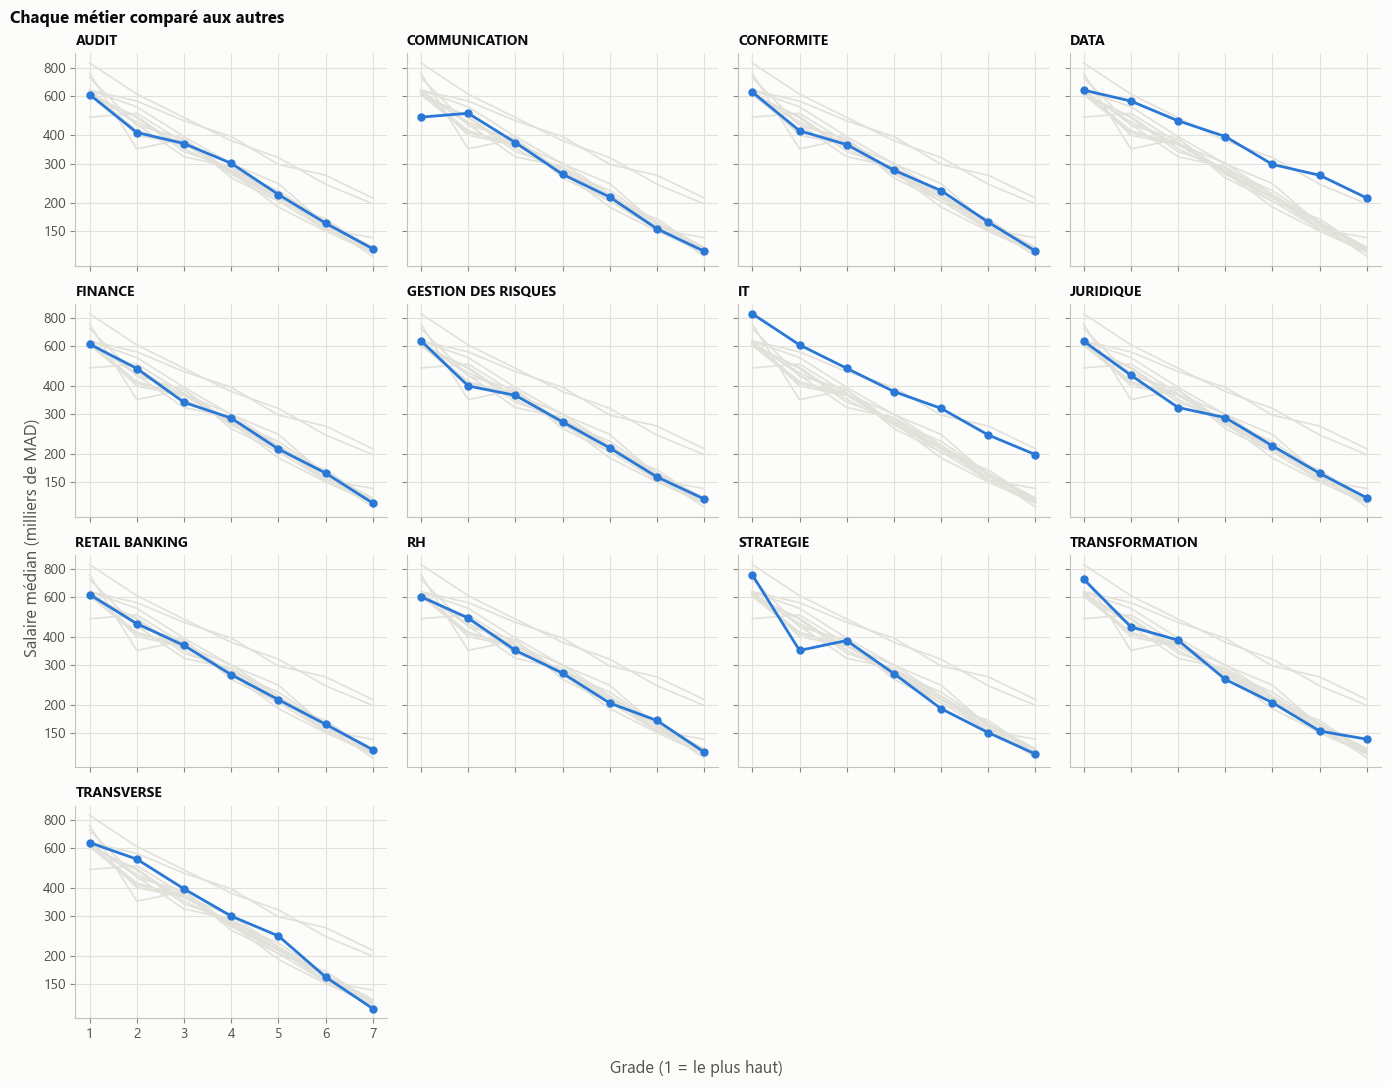

In [12]:
metiers = sorted(df["Job_Family"].unique())
fig, axes = plt.subplots(4, 4, figsize=(14, 11), sharex=True, sharey=True)
for ax, metier in zip(axes.flat, metiers):
    for autre in metiers:
        if autre != metier:
            ax.plot(carte.columns, carte.loc[autre], color=GRILLE, linewidth=1.2)
    ax.plot(carte.columns, carte.loc[metier], color=BLEU, marker="o", markersize=5)
    ax.set_title(metier, fontsize=10)
    echelle_en_pourcentages(ax)
for ax in axes.flat[len(metiers):]:
    ax.set_visible(False)
fig.supxlabel("Grade (1 = le plus haut)", color=ENCRE_2)
fig.supylabel("Salaire médian (milliers de MAD)", color=ENCRE_2)
fig.suptitle("Chaque métier comparé aux autres", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

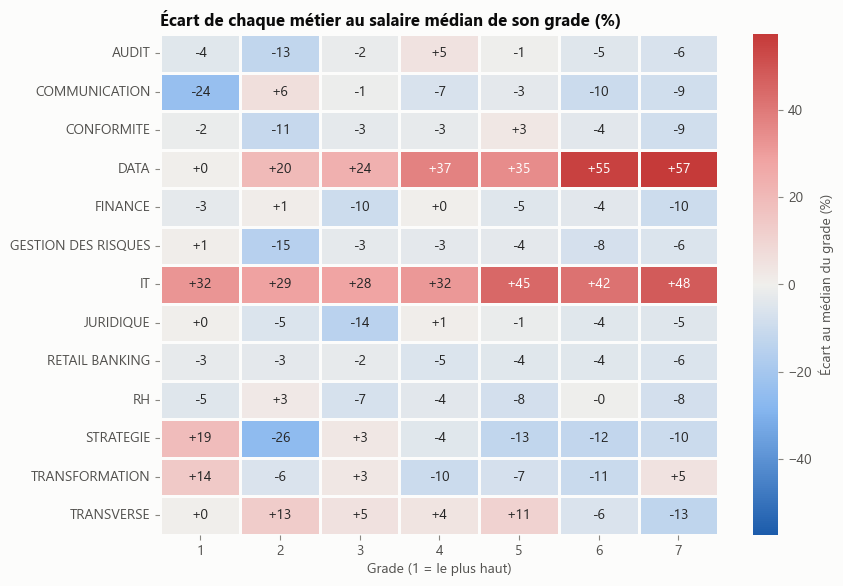

In [13]:
ecart_au_grade = 100 * (carte / df.groupby("Grade")["Fixe_Annuel_MAD"].median() - 1)
borne = np.nanmax(np.abs(ecart_au_grade.values))
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(ecart_au_grade, annot=True, fmt="+.0f", cmap=BLEU_ROUGE, vmin=-borne, vmax=borne,
            linewidths=2, linecolor=FOND, ax=ax, cbar_kws={"label": "Écart au médian du grade (%)"})
ax.set_xlabel("Grade (1 = le plus haut)")
ax.set_ylabel("")
ax.set_title("Écart de chaque métier au salaire médian de son grade (%)")
ax.grid(False)
plt.show()

### Combien de salariés dans chaque case ?

**Pourquoi.** Croiser métier et grade veut dire apprendre une valeur **par case**. Une case de 3 personnes donne une valeur fragile (une seule personne mal payée la fait bouger). Ce graphe dit si le croisement est raisonnable.

**Comment lire.** Le nombre de salariés par case. Les cases claires (peu de monde) sont celles où un croisement serait peu fiable.

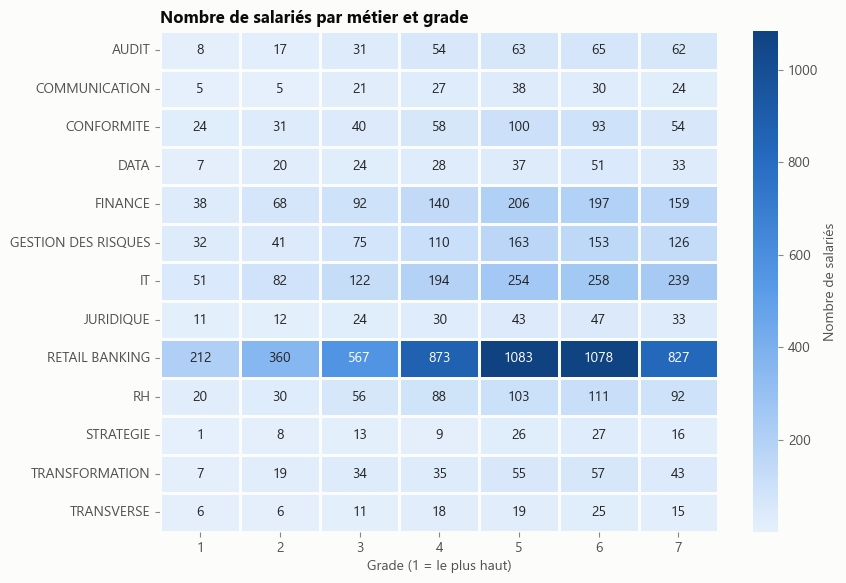

Cases de moins de 10 salariés : 10 sur 91
Job_Family      Grade
STRATEGIE       1        1
COMMUNICATION   1        5
                2        5
TRANSVERSE      1        6
                2        6
DATA            1        7
TRANSFORMATION  1        7
AUDIT           1        8
STRATEGIE       2        8
                4        9


In [14]:
effectif_case = pd.crosstab(df["Job_Family"], df["Grade"])
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(effectif_case, annot=True, fmt="d", cmap=BLEUS, linewidths=2, linecolor=FOND, ax=ax,
            cbar_kws={"label": "Nombre de salariés"})
ax.set_xlabel("Grade (1 = le plus haut)")
ax.set_ylabel("")
ax.set_title("Nombre de salariés par métier et grade")
ax.grid(False)
plt.show()
petites = effectif_case.stack()
print(f"Cases de moins de 10 salariés : {(petites < 10).sum()} sur {petites.size}")
print(petites[petites < 10].sort_values().to_string())

### Le `Mid` de la grille comme seul repère ?

**Pourquoi.** Le `Mid` de la grille est fixé **par case** métier × grade : il contient déjà le croisement. Si les salaires suivent le `Mid`, une seule colonne (`Mid`) pourrait remplacer les 20 colonnes 0/1 de métier et de grade, et fonctionnerait même pour une case qui n'a encore personne.

**Comment lire.** Un point par salarié. Si le nuage suit la diagonale « salaire = Mid » avec la même largeur partout, le `Mid` résume bien métier et grade.

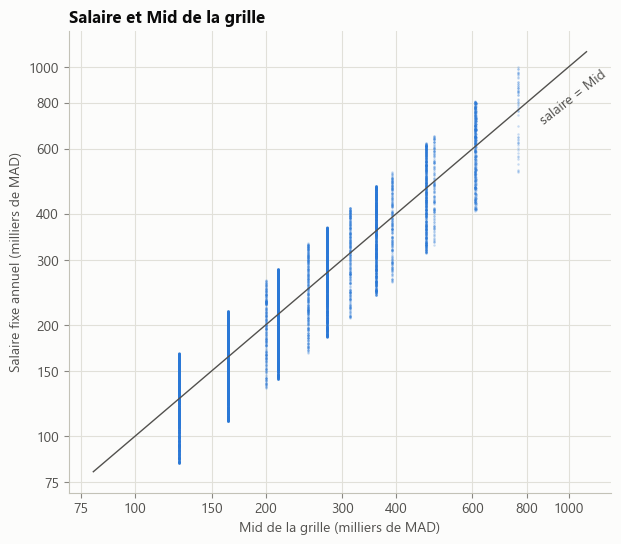

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["Mid"], df["Fixe_Annuel_MAD"], s=3, color=BLEU, alpha=0.25, linewidth=0)
ax.plot([80, 1100], [80, 1100], color=ENCRE_2, linewidth=1)
ax.text(850, 700, "salaire = Mid", color=ENCRE_2, rotation=38)
echelle_en_pourcentages(ax, "x")
echelle_en_pourcentages(ax, "y")
ax.set_xlabel("Mid de la grille (milliers de MAD)")
ax.set_ylabel("Salaire fixe annuel (milliers de MAD)")
ax.set_title("Salaire et Mid de la grille")
plt.show()

## 5. Une fois le métier et le grade connus, qu'est-ce qui reste ?

Le métier et le grade fixent le niveau. La vraie question pour les autres colonnes est : **parmi des collègues du même métier et du même grade**, est-ce que les plus âgés, les plus anciens, les mieux notés… sont mieux payés ?

Pour le voir, on calcule pour chaque salarié son **écart à ses collègues** : de combien (en %) il est au-dessus ou en dessous du salaire médian de son métier + grade. Exemple : un salarié IT de grade 5 payé 260 alors que la médiane des IT de grade 5 est 250 a un écart de +4 %.

Si une colonne compte, l'écart **monte** (ou descend) quand elle augmente. S'il reste **à plat autour de 0**, la colonne n'apporte rien une fois le métier et le grade connus : inutile de la mettre dans la régression.

In [16]:
df["Mediane_Collegues"] = df.groupby(cles)["Fixe_Annuel_MAD"].transform("median")
df["Ecart_Collegues_%"] = 100 * (df["Fixe_Annuel_MAD"] / df["Mediane_Collegues"] - 1)
ECART = "Ecart_Collegues_%"

### La forme de cet écart

**Comment lire.** La répartition des écarts. La forme compte pour la section 7 : le seuil de la régression (`|Reg_Z| ≥ 2`) est pensé pour une **courbe en cloche** (beaucoup de monde au centre, de moins en moins sur les côtés). Une forme **plate** (autant de monde partout entre deux bornes) ou coupée net sur les côtés change ce que veut dire ce seuil.

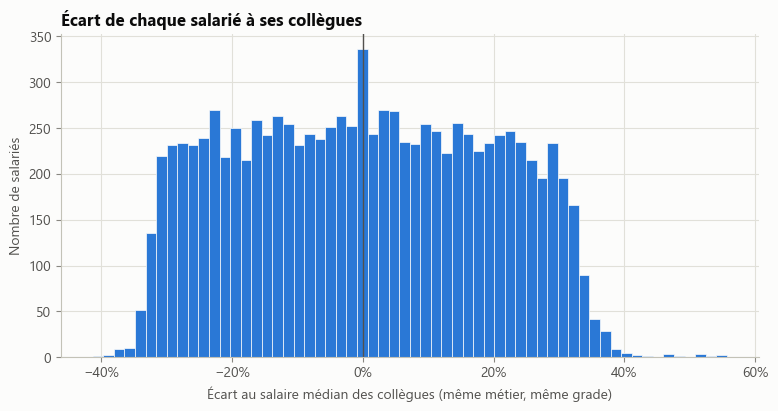

La moitié des salariés est entre -16 % et +16 % ; tous entre -41 % et +56 %


In [17]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(df[ECART], bins=60, color=BLEU, edgecolor=FOND, linewidth=0.5)
ax.axvline(0, color=ENCRE_2, linewidth=1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_xlabel("Écart au salaire médian des collègues (même métier, même grade)")
ax.set_ylabel("Nombre de salariés")
ax.set_title("Écart de chaque salarié à ses collègues")
plt.show()
# Le pic à 0 % : dans chaque case métier + grade, le salarié du milieu est par définition à 0 %
print(f"La moitié des salariés est entre {df[ECART].quantile(0.25):+.0f} % et {df[ECART].quantile(0.75):+.0f} % ; "
      f"tous entre {df[ECART].min():+.0f} % et {df[ECART].max():+.0f} %")

### Âge, ancienneté, note de compétence

**Comment lire.** Chaque point gris est un salarié. La ligne bleue est l'écart **moyen** pour chaque valeur (seulement là où il y a au moins 30 salariés). Une ligne qui monte = la colonne compte ; une ligne plate sur 0 = elle n'apporte rien.

La « force du lien » va de -1 à 1 : 0 = aucun lien, 1 = ça monte toujours ensemble, -1 = l'un monte quand l'autre descend.

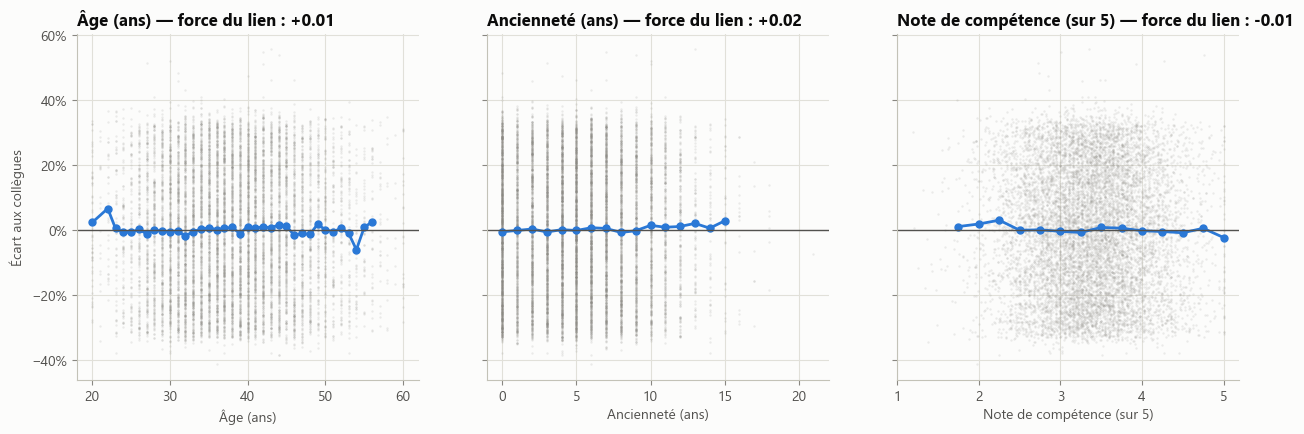

In [18]:
def ecart_moyen_par_valeur(colonne, pas=None, minimum=30):
    valeurs = df[colonne] if pas is None else (df[colonne] / pas).round() * pas
    groupes = df.groupby(valeurs)[ECART].agg(["mean", "size"])
    return groupes[groupes["size"] >= minimum]["mean"]

numeriques = {"Age": ("Âge (ans)", None), "Anciennete": ("Ancienneté (ans)", None),
              "Competence_N1": ("Note de compétence (sur 5)", 0.25)}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (colonne, (titre, pas)) in zip(axes, numeriques.items()):
    ax.scatter(df[colonne], df[ECART], s=3, color=GRIS, alpha=0.15, linewidth=0)
    moyenne = ecart_moyen_par_valeur(colonne, pas)
    ax.plot(moyenne.index, moyenne.values, color=BLEU, marker="o", markersize=5)
    ax.axhline(0, color=ENCRE_2, linewidth=1)
    ax.set_title(f"{titre} — force du lien : {df[colonne].corr(df[ECART]):+.2f}")
    ax.set_xlabel(titre)
axes[0].set_ylabel("Écart aux collègues")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.show()

### Hot_job et case 9-Box

Ces deux colonnes sont des **codes** : Hot_job va de 0 (métier peu tendu sur le marché) à 6 (très tendu), la case 9-Box de 0 à 8. La régression actuelle les traite **comme des nombres** : elle suppose que chaque cran de plus change le salaire du même pourcentage.

**Comment lire.** Pour chaque valeur : l'écart moyen aux collègues (point) et sa fourchette de confiance (trait vertical : là où se trouve vraisemblablement la vraie moyenne). Puis :
- les points **montent régulièrement** → la colonne peut entrer comme un nombre ;
- ils montent et descendent **sans ordre** → il faudrait la passer en catégories (comme le métier) ;
- toutes les fourchettes **touchent la ligne 0** → les différences peuvent être dues au hasard : la colonne n'apporte rien.

Entre parenthèses sous chaque valeur : le nombre de salariés. Moins il y a de monde, plus la fourchette est large ; un point seul, sans fourchette, concerne trop peu de monde pour conclure.

Pour la 9-Box, attention : une case 9-Box est une **position dans une grille** performance × potentiel, pas une quantité. « Case 6 » n'est pas « deux fois case 3 ». La traiter comme un nombre n'a de sens que si le graphe montre une montée régulière.

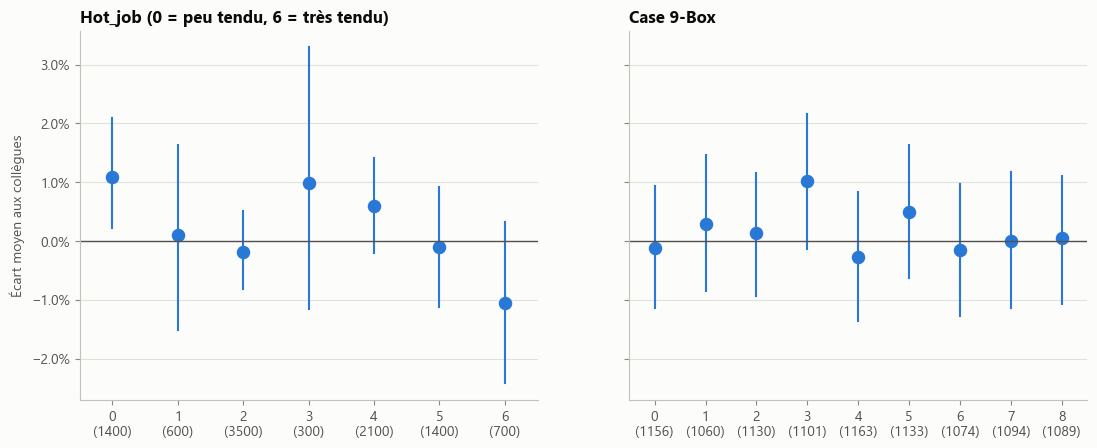

In [19]:
def ecart_moyen_par_groupe(ax, colonne, ordre):
    sns.pointplot(data=df, x=colonne, y=ECART, ax=ax, order=ordre, color=BLEU, linestyle="none",
                  errorbar=("ci", 95), seed=0, markersize=7, err_kws={"linewidth": 1.5})
    ax.axhline(0, color=ENCRE_2, linewidth=1)
    effectif = df[colonne].value_counts()
    ax.set_xticks(range(len(ordre)), [f"{v}\n({effectif.get(v, 0)})" for v in ordre])


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, colonne, titre in [(axes[0], "Hot_job", "Hot_job (0 = peu tendu, 6 = très tendu)"),
                           (axes[1], "Positionnement_9BOX", "Case 9-Box")]:
    ecart_moyen_par_groupe(ax, colonne, sorted(df[colonne].unique()))
    ax.set_title(titre)
    ax.set_xlabel("")
axes[0].set_ylabel("Écart moyen aux collègues")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
plt.show()

### Sexe, pôle, tranche d'ancienneté

**Comment lire.** Même lecture que ci-dessus.

Le **sexe** n'a pas sa place dans la régression : le modèle apprendrait à prédire un salaire différent pour une femme et un homme au même poste, et ferait passer pour « normal » un écart qu'on cherche justement à repérer. On le regarde ici seulement pour vérifier qu'il n'y a pas d'écart caché (l'étude complète est faite par `src/anomaly_ecarts_hommes_femmes.py`).

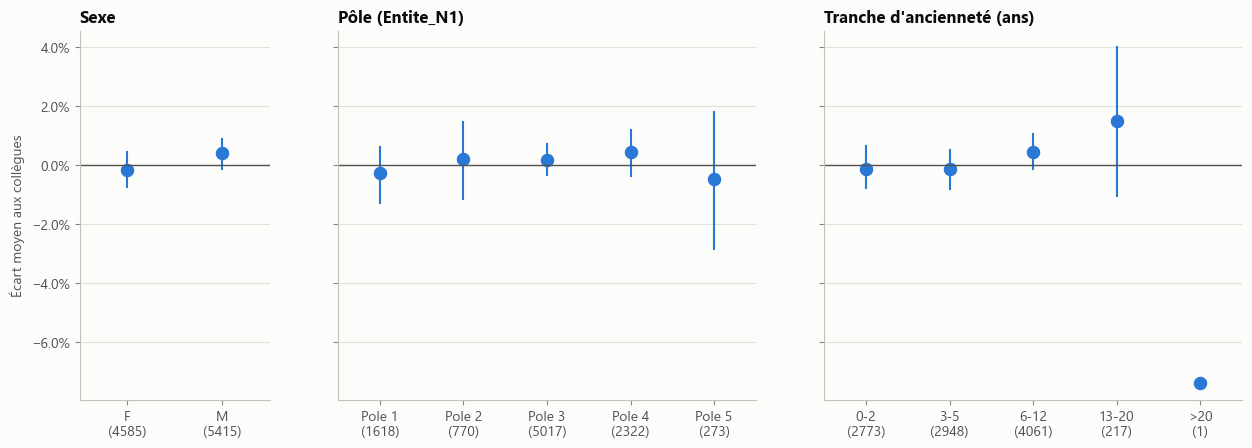

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True, gridspec_kw={"width_ratios": [1, 2.2, 2.2]})
for ax, colonne, titre, ordre in [
        (axes[0], "Sexe", "Sexe", ["F", "M"]),
        (axes[1], "Entite_N1", "Pôle (Entite_N1)", sorted(df["Entite_N1"].unique())),
        (axes[2], "Anciennete_Tranche", "Tranche d'ancienneté (ans)", ["0-2", "3-5", "6-12", "13-20", ">20"])]:
    ecart_moyen_par_groupe(ax, colonne, ordre)
    ax.set_title(titre)
    ax.set_xlabel("")
axes[0].set_ylabel("Écart moyen aux collègues")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
plt.show()

## 6. Des colonnes qui disent la même chose ?

Mettre dans la régression deux colonnes qui racontent la même histoire n'ajoute rien, et brouille la lecture : le modèle ne sait plus à laquelle attribuer l'effet.

### Les liens entre colonnes candidates

**Comment lire.** Pour chaque paire de colonnes, la force du lien (de -1 à 1). Rouge = elles montent ensemble ; bleu = l'une monte quand l'autre descend ; gris clair = aucun lien. Deux colonnes candidates très liées entre elles (au-delà de ±0,7) : on n'en garde qu'une. La ligne « Salaire (en %) » montre au passage ce qui est lié au salaire lui-même.

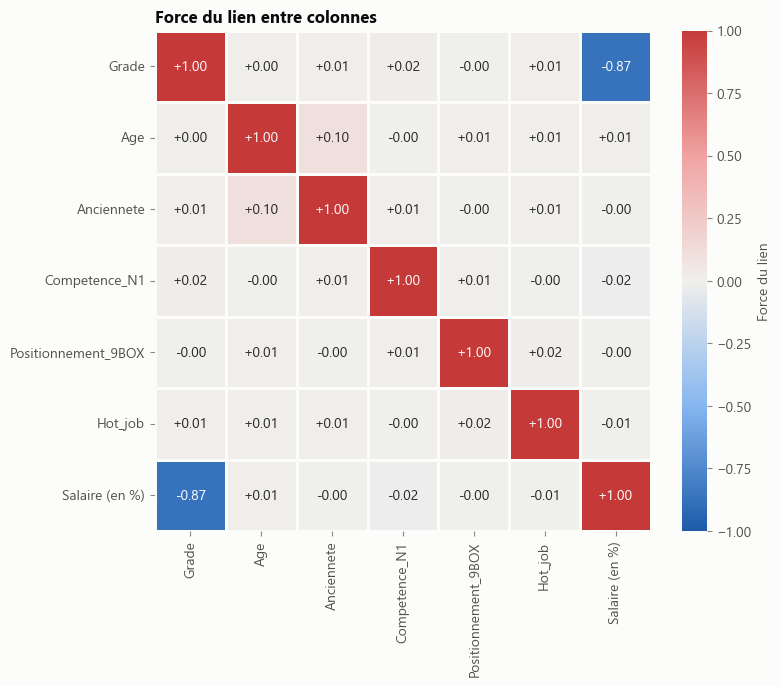

In [21]:
candidates = df[["Grade", "Age", "Anciennete", "Competence_N1", "Positionnement_9BOX", "Hot_job"]].copy()
candidates["Salaire (en %)"] = np.log(df["Fixe_Annuel_MAD"])
liens = candidates.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(liens, annot=True, fmt="+.2f", cmap=BLEU_ROUGE, vmin=-1, vmax=1, linewidths=2, linecolor=FOND,
            ax=ax, cbar_kws={"label": "Force du lien"})
ax.set_title("Force du lien entre colonnes")
ax.grid(False)
plt.show()

### Âge et ancienneté

**Pourquoi.** On s'attend à ce que les plus âgés soient aussi les plus anciens. Si c'est très marqué, mettre les deux revient à compter deux fois la même chose.

**Comment lire.** Un point par salarié (légèrement décalé au hasard pour qu'ils ne se cachent pas les uns les autres, car âge et ancienneté sont des nombres entiers). La droite grise est la limite « entré à 18 ans » : personne ne peut être au-dessus.

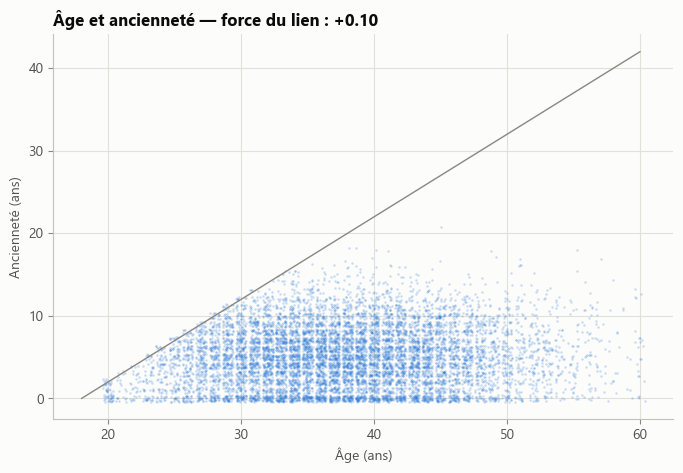

In [22]:
bruit = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Age"] + bruit.uniform(-0.4, 0.4, len(df)), df["Anciennete"] + bruit.uniform(-0.4, 0.4, len(df)),
           s=3, color=BLEU, alpha=0.25, linewidth=0)
ages = np.array([18, 60])
ax.plot(ages, ages - 18, color=GRIS, linewidth=1)
ax.set_xlabel("Âge (ans)")
ax.set_ylabel("Ancienneté (ans)")
ax.set_title(f"Âge et ancienneté — force du lien : {df['Age'].corr(df['Anciennete']):+.2f}")
plt.show()

### Métier et pôle

**Pourquoi.** Si chaque métier appartient à un seul pôle, le pôle ne fait que répéter le métier : on ne met jamais les deux.

**Comment lire.** Nombre de salariés de chaque métier dans chaque pôle (case vide = personne). Un métier sur une seule colonne = rattaché à un seul pôle.

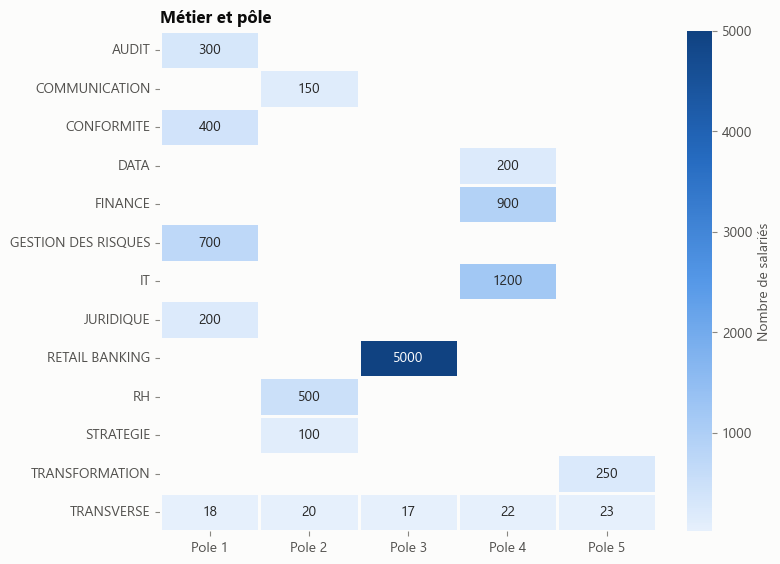

In [23]:
metier_pole = pd.crosstab(df["Job_Family"], df["Entite_N1"])
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(metier_pole, annot=True, fmt="d", cmap=BLEUS, mask=metier_pole == 0, linewidths=2, linecolor=FOND,
            ax=ax, cbar_kws={"label": "Nombre de salariés"})
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Métier et pôle")
ax.grid(False)
plt.show()

### Le poste (Job_Title)

**Pourquoi.** Le poste est la description la plus fine du travail. Mais pour qu'une régression apprenne une valeur par poste, il faut assez de monde dans chaque poste.

**Comment lire.** Combien de postes ont 1 salarié, 2 salariés, etc. Si la plupart des postes n'ont qu'une poignée de salariés, le poste est trop éclaté pour être une colonne. On vérifie aussi que le Hot_job est le même pour tous les salariés d'un poste : dans ce cas, Hot_job est en fait **le résumé du poste**.

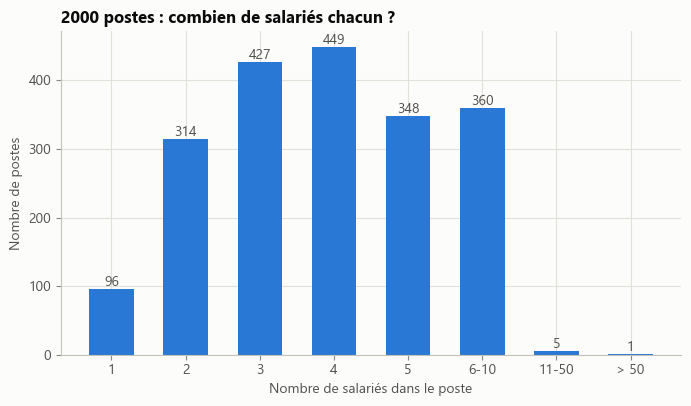

Les plus gros postes : {'JT0001': 2000, 'JT1515': 12, 'JT0633': 11}
Un seul Hot_job par poste : True


In [24]:
taille_poste = df.groupby("Job_Title").size()
tranches = pd.cut(taille_poste, [0, 1, 2, 3, 4, 5, 10, 50, np.inf], labels=["1", "2", "3", "4", "5", "6-10", "11-50", "> 50"])
compte = tranches.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(compte.index.astype(str), compte.values, color=BLEU, width=0.6)
for x, v in enumerate(compte.values):
    ax.text(x, v, f"{v}", ha="center", va="bottom", color=ENCRE_2)
ax.set_xlabel("Nombre de salariés dans le poste")
ax.set_ylabel("Nombre de postes")
ax.set_title(f"{len(taille_poste)} postes : combien de salariés chacun ?")
plt.show()
print("Les plus gros postes :", taille_poste.nlargest(3).to_dict())
print("Un seul Hot_job par poste :", bool((df.groupby("Job_Title")["Hot_job"].nunique() == 1).all()))

## 7. Mettre les choix à l'épreuve

Les graphes donnent des pistes ; ici, on les essaie. Même méthode que `src/anomaly_signal_regression.py` (`LinearRegression`, colonnes 0/1 pour le métier et le grade, log du salaire), avec une différence : on entraîne le modèle sur **80 %** des salariés, et on le note sur les **20 %** restants, qu'il n'a jamais vus. C'est la situation réelle d'un nouvel embauché.

Deux notes, calculées en milliers de MAD pour tous les essais (pour qu'ils soient comparables, avec ou sans log) :
- **part expliquée (R²)** : 1 = le modèle retrouve parfaitement chaque salaire ; 0 = il ne fait pas mieux que donner le salaire moyen à tout le monde ;
- **erreur moyenne (%)** : de combien, en moyenne, le salaire prédit se trompe.

In [25]:
COLONNES_EMBAUCHE = ["Job_Family", "Grade", "Age", "Hot_job"]
COLONNES_SALARIE = ["Job_Family", "Grade", "Anciennete", "Age", "Competence_N1", "Positionnement_9BOX", "Hot_job"]

# Colonnes à transformer en colonnes 0/1 (une par valeur) ; les autres entrent comme des nombres
EN_CATEGORIES = ["Job_Family", "Grade", "Metier_x_Grade", "Hot_job_categories", "Entite_N1"]
df["Metier_x_Grade"] = df["Job_Family"] + " / " + df["Grade"].astype(str)
df["Grade_nombre"] = df["Grade"]
df["Log_Mid"] = np.log(df["Mid"])
df["Hot_job_categories"] = df["Hot_job"].astype(str)

lignes_entrainement, lignes_test = train_test_split(df.index, test_size=0.2, random_state=42)
reel = df.loc[lignes_test, "Fixe_Annuel_MAD"]


def essayer(colonnes, log=True):
    X = pd.get_dummies(df[colonnes], columns=[c for c in colonnes if c in EN_CATEGORIES], dtype=float)
    Y = np.log(df["Fixe_Annuel_MAD"]) if log else df["Fixe_Annuel_MAD"]
    modele = LinearRegression().fit(X.loc[lignes_entrainement], Y.loc[lignes_entrainement])
    prevu = modele.predict(X.loc[lignes_test])
    if log:
        prevu = np.exp(prevu)
    notes = {"part expliquée (R²)": r2_score(reel, prevu),
             "erreur moyenne (%)": 100 * (np.abs(prevu - reel) / reel).mean()}
    return notes, prevu


essais = {
    "Grade seul": (["Grade"], True),
    "Métier seul": (["Job_Family"], True),
    "Métier + grade, sans log": (["Job_Family", "Grade"], False),
    "Métier + grade": (["Job_Family", "Grade"], True),
    "Métier + grade compté comme un nombre": (["Job_Family", "Grade_nombre"], True),
    "Métier × grade (une valeur par case)": (["Metier_x_Grade"], True),
    "Mid de la grille seul": (["Log_Mid"], True),
    "Colonnes embauche actuelles": (COLONNES_EMBAUCHE, True),
    "Colonnes salarié actuelles": (COLONNES_SALARIE, True),
}
previsions = {}
resultats = {}
for nom, (colonnes, log) in essais.items():
    resultats[nom], previsions[nom] = essayer(colonnes, log)
resultats = pd.DataFrame(resultats).T.sort_values("erreur moyenne (%)")
resultats.round(3)

,part expliquée (R²),erreur moyenne (%)
Mid de la grille seul,0.845,16.868
Métier + grade,0.843,16.897
Métier + grade compté comme un nombre,0.843,16.904
Colonnes embauche actuelles,0.843,16.907
Métier × grade (une valeur par case),0.841,16.922
Colonnes salarié actuelles,0.843,16.929
"Métier + grade, sans log",0.841,17.255
Grade seul,0.772,19.303
Métier seul,0.021,39.424


**Comment lire.** Chaque barre est un essai ; en bleu, les deux choix actuels du fichier de régression, en gris les autres. Pour la part expliquée, plus long = mieux ; pour l'erreur, plus court = mieux. Deux essais presque à égalité : on prend **le plus simple** (le moins de colonnes).

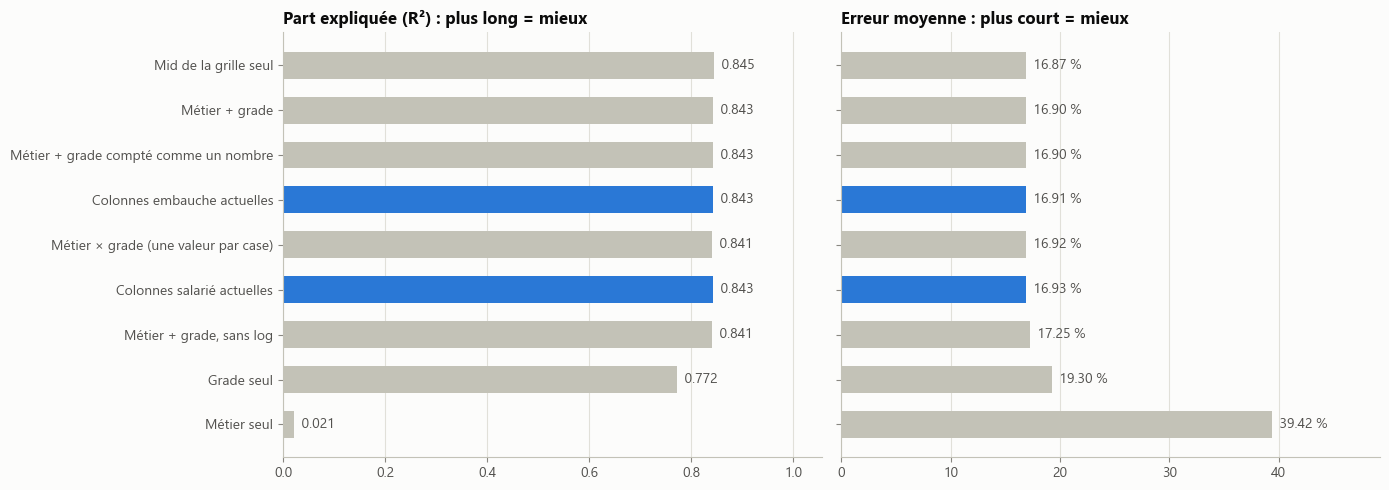

In [26]:
couleurs = [BLEU if "actuelles" in nom else GRIS_CLAIR for nom in resultats.index]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, note, titre, format_ in [(ax1, "part expliquée (R²)", "Part expliquée (R²) : plus long = mieux", "{:.3f}"),
                                 (ax2, "erreur moyenne (%)", "Erreur moyenne : plus court = mieux", "{:.2f} %")]:
    ax.barh(resultats.index, resultats[note], color=couleurs, height=0.6)
    for y, v in enumerate(resultats[note]):
        ax.text(v, y, "  " + format_.format(v), va="center", color=ENCRE_2)
    ax.set_title(titre)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, resultats[note].max() * 1.25)
ax1.invert_yaxis()
plt.tight_layout()
plt.show()

### Que rapporte chaque colonne ajoutée à « métier + grade » ?

**Pourquoi.** C'est la question pour `COLONNES_EMBAUCHE` et `COLONNES_SALARIE` : on part de métier + grade, et on ajoute **une** colonne à la fois.

**Comment lire.** De combien l'erreur moyenne change (en points de %). Une barre **vers la gauche** (négative) = l'erreur baisse, la colonne aide. Une barre minuscule, ou vers la droite = la colonne n'aide pas (voire gêne un peu) : on peut la retirer. L'axe va toujours au moins de -0,5 à +0,5 point, pour qu'un changement minuscule paraisse minuscule.

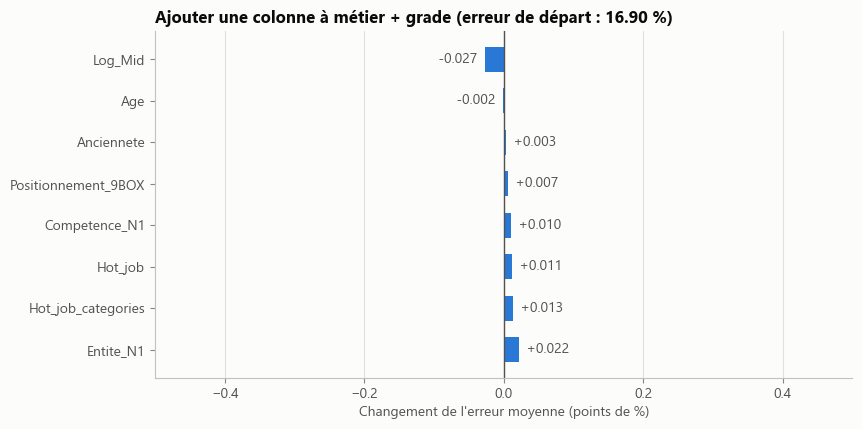

In [27]:
base, _ = essayer(["Job_Family", "Grade"])
ajouts = {}
for colonne in ["Age", "Anciennete", "Competence_N1", "Positionnement_9BOX", "Hot_job", "Hot_job_categories",
                "Entite_N1", "Log_Mid"]:
    notes, _ = essayer(["Job_Family", "Grade", colonne])
    ajouts[colonne] = notes["erreur moyenne (%)"] - base["erreur moyenne (%)"]
ajouts = pd.Series(ajouts).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(ajouts.index, ajouts.values, color=BLEU, height=0.6)
ax.axvline(0, color=ENCRE_2, linewidth=1)
for y, v in enumerate(ajouts.values):
    ax.text(v, y, f"  {v:+.3f}  ", va="center", ha="left" if v >= 0 else "right", color=ENCRE_2)
limite = max(0.5, ajouts.abs().max() * 1.4)
ax.set_xlim(-limite, limite)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("Changement de l'erreur moyenne (points de %)")
ax.set_title(f"Ajouter une colonne à métier + grade (erreur de départ : {base['erreur moyenne (%)']:.2f} %)")
plt.show()

### Salaire prédit et salaire réel

**Comment lire.** Pour les salariés mis de côté (jamais vus par le modèle « métier + grade ») : un point par salarié. Sur la diagonale, la prédiction est exacte. La largeur du nuage autour de la diagonale, c'est ce que le modèle ne peut pas expliquer avec ces colonnes.

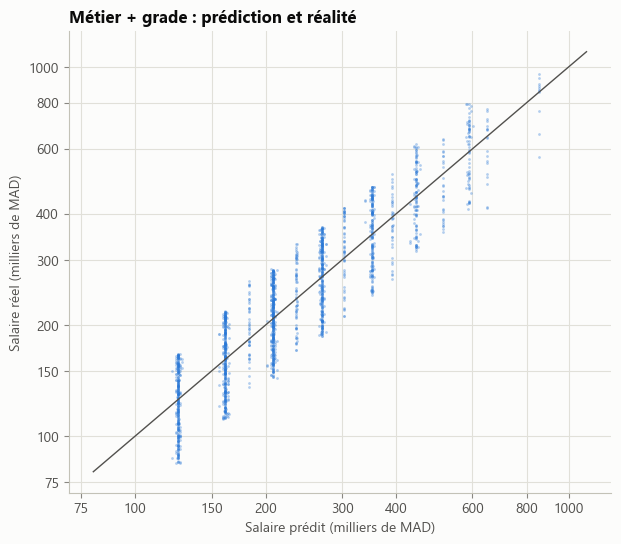

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(previsions["Métier + grade"], reel, s=4, color=BLEU, alpha=0.35, linewidth=0)
ax.plot([80, 1100], [80, 1100], color=ENCRE_2, linewidth=1)
echelle_en_pourcentages(ax, "x")
echelle_en_pourcentages(ax, "y")
ax.set_xlabel("Salaire prédit (milliers de MAD)")
ax.set_ylabel("Salaire réel (milliers de MAD)")
ax.set_title("Métier + grade : prédiction et réalité")
plt.show()

### Le seuil `|Reg_Z| ≥ 2` : que veut-il dire sur ces données ?

**Pourquoi.** La régression signale un salaire quand `Reg_Z`, l'écart au salaire attendu divisé par l'erreur normale du modèle, dépasse 2 (au-dessus ou en dessous). Ce seuil vient de la **courbe en cloche** : quand les écarts ont cette forme, environ 5 % des gens dépassent 2. Si les écarts ont une autre forme, le même seuil peut signaler beaucoup plus ou beaucoup moins de monde.

**Comment lire.** On refait exactement le calcul du fichier de régression avec les colonnes embauche actuelles, sur tous les salariés. Les barres : la répartition réelle des `Reg_Z`. La courbe : ce qu'on aurait avec une cloche parfaite. Les traits verticaux : le seuil à -2 et +2. Si les barres s'arrêtent avant les traits, le seuil ne signalera presque personne parmi les salariés actuels ; il faudra alors le choisir autrement (par exemple d'après la part de salariés qu'on veut revoir).

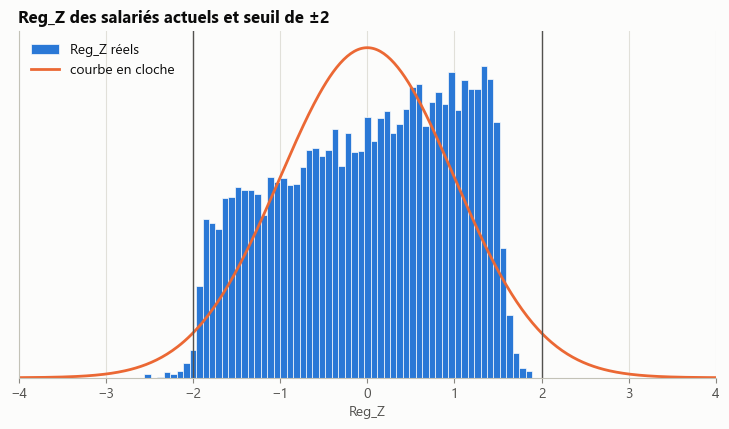

Salariés au-delà de ±2 : 0.4% (une courbe en cloche en donnerait 4,6 %)
Reg_Z va de -2.56 à 1.89
Pour revoir 1% des salariés, le seuil serait |Reg_Z| ≥ 1.92
Pour revoir 5% des salariés, le seuil serait |Reg_Z| ≥ 1.71
Pour revoir 10% des salariés, le seuil serait |Reg_Z| ≥ 1.54


In [29]:
X = pd.get_dummies(df[COLONNES_EMBAUCHE], columns=["Job_Family", "Grade"], dtype=float)
Y = np.log(df["Fixe_Annuel_MAD"])
modele = LinearRegression().fit(X, Y)
Y_pred = modele.predict(X)
reg_z = (Y - Y_pred) / (Y - Y_pred).std()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(reg_z, bins=60, density=True, color=BLEU, edgecolor=FOND, linewidth=0.5, label="Reg_Z réels")
z = np.linspace(-4, 4, 400)
ax.plot(z, np.exp(-z ** 2 / 2) / np.sqrt(2 * np.pi), color=ORANGE, label="courbe en cloche")
for seuil in (-2, 2):
    ax.axvline(seuil, color=ENCRE_2, linewidth=1)
ax.set_xlim(-4, 4)
ax.set_xlabel("Reg_Z")
ax.set_yticks([])
ax.grid(axis="y", visible=False)
ax.legend(loc="upper left")
ax.set_title("Reg_Z des salariés actuels et seuil de ±2")
plt.show()

print(f"Salariés au-delà de ±2 : {(reg_z.abs() >= 2).mean():.1%} (une courbe en cloche en donnerait 4,6 %)")
print(f"Reg_Z va de {reg_z.min():.2f} à {reg_z.max():.2f}")
for part in (0.01, 0.05, 0.10):
    print(f"Pour revoir {part:.0%} des salariés, le seuil serait |Reg_Z| ≥ {reg_z.abs().quantile(1 - part):.2f}")

## Et après

Une fois les choix faits, ils se reportent dans `src/anomaly_signal_regression.py` :
- les colonnes : `COLONNES_EMBAUCHE` et `COLONNES_SALARIE` ;
- la façon de les utiliser : `construire_X` (quelles colonnes passent en 0/1) ;
- le seuil : `seuil` dans `evaluer`.